## Loading libraries

In [3]:
#pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
#pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.5/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.5/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.5/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.8/101.7 MB 430.1 kB/s eta 0:03:55
   ---------------------------------------- 0.8/101.7 MB 430.1 kB/s eta 0:03:55
   ---------------------------------------- 0.8/101.7 MB 430.1 kB/s eta 0:03:55
   ---------------------------------------- 0.8/101.7 MB 430.1 kB/s eta 0:03:55
   ---------------------------------------- 1.0/101.7 MB 384.2 kB/s eta 0:04:22
   ---------------------------------------- 1.0/101.7 MB 384.2 kB/

In [6]:
#pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
#pip install shap

   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 4.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.6 MB 5.0 MB/s eta 0:00:03
   ---- ----------------------------------- 1.6/15.6 MB 3.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.8/15.6 MB 3.7 MB/s eta 0:00:04
   ------ --------------------------------- 2.4/15.6 MB 2.8 MB/s eta 0:00:05
   -------- ------------------------------- 3.1/15.6 MB 3.0 MB/s eta 0:00:05
   ---------- ----------------------------- 3.9/15.6 MB 3.1 MB/s eta 0:00:04
   ----------- ---------------------------- 4.5/15.6 MB 3.1 MB/s eta 0:00:04
   ------------- -------------------------- 5.2/15.6 MB 3.0 MB/s eta 0:00:04
   -------------- ------------------------- 5.8/15.6 MB 3.1 MB/s eta 0:00:04
   ---------------- ----------------------- 6.6/15.6 MB 3.0 MB/s eta 0:00:03
   ------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [ ]:
#pip install imblearn

In [95]:
# ============================================================
# STEP -1 - Importing Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from tqdm.auto import tqdm
import time
from lightgbm import LGBMClassifier
import shap
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import NearMiss
import warnings
from tqdm import tqdm




In [96]:
warnings.filterwarnings("ignore")


## Step 0. Loading the Dataset

In [97]:
# ============================================================
# STEP 0 - Loading the Dataset
# ============================================================

##df = pd.read_sas("/Users/fatimaiqbal/Desktop/Data Mining/LLCP2023.XPT", format="xport", encoding="latin1")

##ozlem version
##df = pd.read_sas(r'C:\Users\olcer\OneDrive\Desktop\Data Mining Project\LLCP2023XPT\LLCP2023.XPT')

## Muhammad version
zip_path = r'C:\Users\m.murodzoda\Downloads\LLCP2023.XPT.zip'
sas_filename = 'LLCP2023.XPT'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(sas_filename) as f:
        df = pd.read_sas(f, format="xport", encoding="latin1")

df.shape

(433323, 350)

In [98]:
df['_BMI5'].describe()

count    392788.000000
mean       2847.928783
std         654.197490
min        1202.000000
25%        2410.000000
50%        2740.000000
75%        3162.000000
max        9984.000000
Name: _BMI5, dtype: float64

## STEP 1 - Column Selection and STEP 2 - Duplicate Removal

In [99]:

#  2023 data

# ============================================================
# STEP 1 - Column Selection
# ============================================================
cols = ['SEQNO', '_PSU', '_STATE', 'QSTVER', 'QSTLANG', 'DIABETE4', '_RFHYPE6', 'TOLDHI3', '_CHOLCH3',
        '_BMI5', '_RFBMI5', 'SMOKE100', '_SMOKER3', 'CVDSTRK3', '_MICHD', '_TOTINDA',
        '_RFDRHV8', '_HLTHPL1', 'MEDCOST1', 'GENHLTH', 'MENTHLTH',
        'PHYSHLTH', 'DIFFWALK', 'SEXVAR', '_AGEG5YR', 'EDUCA', 'INCOME3',
        'ADDEPEV3', 'HAVARTH4', 'CHCKDNY2']

df = df[cols]
print(f"Step 1 - After column selection: {df.shape}")

# ============================================================
# STEP 2 - Duplicate Removal
# ============================================================
before_dedup = len(df)
df = df.drop_duplicates(subset=['SEQNO', 'QSTVER', 'QSTLANG', '_STATE'])
after_dedup = len(df)
print(f"\nStep 2 - Duplicates removed: {before_dedup - after_dedup}")
print(f"After deduplication: {df.shape}")

Step 1 - After column selection: (433323, 30)

Step 2 - Duplicates removed: 0
After deduplication: (433323, 30)


## STEP 3 - Missing Value Removal

In [100]:
# ============================================================
# STEP 3 - Missing Value Removal
# ============================================================
print(f"\nStep 3 - Row reduction per column:")
temp_df = df.copy()
missing_cols = df.columns[df.isnull().any()].tolist()
for col in missing_cols:
    before = len(temp_df)
    temp_df = temp_df.dropna(subset=[col])
    after = len(temp_df)
    if before - after > 0:
        print(f"  Dropping NaN in {col}: -{before - after} rows (remaining: {after})")

df = df.dropna()
print(f"\nStep 4 - Final shape after dropna: {df.shape}")


Step 3 - Row reduction per column:
  Dropping NaN in DIABETE4: -5 rows (remaining: 433318)
  Dropping NaN in TOLDHI3: -51809 rows (remaining: 381509)
  Dropping NaN in _BMI5: -33917 rows (remaining: 347592)
  Dropping NaN in SMOKE100: -5626 rows (remaining: 341966)
  Dropping NaN in CVDSTRK3: -1 rows (remaining: 341965)
  Dropping NaN in _MICHD: -3096 rows (remaining: 338869)
  Dropping NaN in GENHLTH: -1 rows (remaining: 338868)
  Dropping NaN in EDUCA: -1 rows (remaining: 338867)

Step 4 - Final shape after dropna: (338867, 30)


## STEP 4 -  Value Recoding and Outlier Management
## And Establishing proxies for risk groups and diseases

In [101]:
# ============================================================
# STEP 4 -  Value Recoding and Outlier Management
# ============================================================
print("\nStep 4 - Outlier management and value recoding...")

# DIABETE4 - target variable
# 1 = Diabetic, 4 = Pre-diabetes -> keep as 1
# 2 = Pregnant only, 3 = No -> keep as 0
# 7, 9 = Don't know/Refused -> drop

df = df[~df['DIABETE4'].isin([7.0, 9.0])]  # drop unknowns first
df['DIABETE4'] = (df['DIABETE4'].isin([1.0, 4.0])).astype(int)  # 1 if diabetic, 0 otherwise

# _RFHYPE6 - high blood pressure
## Yes 1, No 2 -> Yes 1, No 0
df['_RFHYPE6'] = df['_RFHYPE6'].replace({1:0, 2:1})
df = df[df['_RFHYPE6'] != 9]

# TOLDHI3 - told high cholesterol
## No, 2 -> No, 0
df['TOLDHI3'] = df['TOLDHI3'].replace({2:0})
df = df[~df['TOLDHI3'].isin([7, 9])]

# _CHOLCH3 - cholesterol check
#Did not have cholesterol check 2, had never had cholesterol check 3 -> No 0
df['_CHOLCH3'] = df['_CHOLCH3'].replace({2:0, 3:0})
df = df[df['_CHOLCH3'] != 9]

# _BMI5 - BMI (divide by 100)
df['_BMI5'] = df['_BMI5'].div(100)

# _RFBMI5 - overweight/obese flag
## 12 < BMI <25,1 --> No,0
## BMI >= 25,2 --> Yes,1
df['_RFBMI5'] = df['_RFBMI5'].replace({1:0, 2:1})
df = df[df['_RFBMI5'] != 9]

# SMOKE100 - smoked 100
# Smoked 100 cigarettes in lifetime: No, 2 -> No, 0
df['SMOKE100'] = df['SMOKE100'].replace({2:0})
df = df[~df['SMOKE100'].isin([7, 9])]

# _SMOKER3 - smoker status (keep ordinal 1-4)
#Current Smoker - smokes everyday, 1
#Current Smoker - smokes some days, 2
#Former Smoker, 3
#Never Smoker, 4
df = df[df['_SMOKER3'] != 9]

# CVDSTRK3 - ever had stroke
# No, 2 -> No, 0
df['CVDSTRK3'] = df['CVDSTRK3'].replace({2:0})
df = df[~df['CVDSTRK3'].isin([7, 9])]

# _MICHD - coronary heart disease
# No, 2 -> No, 0
df['_MICHD'] = df['_MICHD'].replace({2:0})

# _TOTINDA - physical activity
# No, 2 -> No, 0
df['_TOTINDA'] = df['_TOTINDA'].replace({2:0})
df = df[df['_TOTINDA'] != 9]

# _RFDRHV8 - heavy drinker
# No,1 -> No,0
# Yes,2 -> Yes,1
df['_RFDRHV8'] = df['_RFDRHV8'].replace({1:0, 2:1})
df = df[df['_RFDRHV8'] != 9]

# _HLTHPL1 - health insurance
# No, 2 -> No, 0
df['_HLTHPL1'] = df['_HLTHPL1'].replace({2:0})
df = df[df['_HLTHPL1'] != 9]

# MEDCOST1 - could not see doctor due to cost
# No, 2 -> No, 0
df['MEDCOST1'] = df['MEDCOST1'].replace({2:0})
df = df[~df['MEDCOST1'].isin([7, 9])]

# GENHLTH - general health (keep ordinal 1-5)
# 1 Good to 5 Poor, 7 Don't know, 9 Refused
df = df[~df['GENHLTH'].isin([7, 9])]

# MENTHLTH - days mental health not good
# 88 None, 77 Don't know, 99 Refused
df['MENTHLTH'] = df['MENTHLTH'].replace({88:0})
df = df[~df['MENTHLTH'].isin([77, 99])]

# PHYSHLTH - days physical health not good
# 88 None, 77 Don't know, 99 Refused
df['PHYSHLTH'] = df['PHYSHLTH'].replace({88:0})
df = df[~df['PHYSHLTH'].isin([77, 99])]

# DIFFWALK - difficulty walking
# No, 2 -> No, 0
df['DIFFWALK'] = df['DIFFWALK'].replace({2:0})
df = df[~df['DIFFWALK'].isin([7, 9])]

# SEXVAR - sex (1=Male, 2=Female)
# Female, 2 -> Female, 0
df['SEXVAR'] = df['SEXVAR'].replace({2:0})

# _AGEG5YR - age group (keep ordinal 1-13)
df = df[df['_AGEG5YR'] != 14]

# EDUCA - education (keep ordinal 1-6)
df = df[df['EDUCA'] != 9]

# INCOME3 - income (keep ordinal 1-11)
df = df[~df['INCOME3'].isin([77, 99])]

# ADDEPEV3 - depression
# No, 2 -> No, 0
df['ADDEPEV3'] = df['ADDEPEV3'].replace({2:0})
df = df[~df['ADDEPEV3'].isin([7, 9])]

# HAVARTH4 - arthritis
# No, 2 -> No, 0
df['HAVARTH4'] = df['HAVARTH4'].replace({2:0})
df = df[~df['HAVARTH4'].isin([7, 9])]

# CHCKDNY2 - kidney disease
# No, 2 -> No, 0
df['CHCKDNY2'] = df['CHCKDNY2'].replace({2:0})
df = df[~df['CHCKDNY2'].isin([7, 9])]


# ============================================================
# STEP 4.5 - Establishing proxies for risk groups and diseases
# ============================================================


# 1. Metabolic Syndrome (MetS) Proxy
# Condition: Has the three other of the four syntoms of a metabolic syndrome (diabetis is the forth syndrome)

is_obese = df['_RFBMI5'] >= 1
has_htn = df['_RFHYPE6'] == 1
has_chol = df['TOLDHI3'] == 1

mets_score = is_obese.astype(int) + has_htn.astype(int) + has_chol.astype(int)

# Set flag to 1 if score = 3, otherwise 0
df['Metabolic_Syndrome'] = mets_score


# 2. High Cardiovascular Risk (ASCVD) Proxy
 # Condition: History of heart attack/stroke OR dangerous combinations

hist_cvd = (df['_MICHD'] == 1) | (df['CVDSTRK3'] == 1)

# 1 (Everyday) and 2 (Some days) represent current smokers
is_current_smoker = df['_SMOKER3'].isin([1, 2])

htn_chol_smoke = (df['_RFHYPE6'] == 1) & (df['TOLDHI3'] == 1) & is_current_smoker

 # If any conditions are met
high_risk_condition = hist_cvd | htn_chol_smoke
df['High_CVD_Risk_Profile'] = high_risk_condition.astype(int)


# 3. Chronic Comorbidity Burden (CCI Proxy)
# Sum of the binary indicators of the 4 major organ diseases, excluding diabetis

comorbidity_cols = [
        '_MICHD',
        'CVDSTRK3',
        'CHCKDNY2'
    ]

df['Comorbidity_Count'] = df[comorbidity_cols].sum(axis=1)


# 4. Behavioral Risk / Healthy Lifestyle Score (AHA Proxy)
# Starts at 0, +1 for each positive factor

score_smoke = df['_SMOKER3'].isin([3, 4]).astype(int)
score_active = (df['_TOTINDA'] == 1).astype(int)
score_bmi = (df['_RFBMI5'] == 0).astype(int)
score_drink = (df['_RFDRHV8'] == 0).astype(int)

df['Healthy_Lifestyle_Score'] = score_smoke + score_active + score_bmi + score_drink

print(f"After outlier management and recoding: {df.shape}")


Step 4 - Outlier management and value recoding...
After outlier management and recoding: (259269, 34)


## STEP 5 - Rename Columns

In [102]:
# ============================================================
# STEP 5 - Rename Columns
# ============================================================
df= df.rename(columns={
    'SEQNO': 'SequenceNo',
    '_PSU': 'PSU',
    '_STATE': 'State',
    'QSTVER': 'QuestionnaireVersion',
    'QSTLANG': 'QuestionnaireLang',
    'DIABETE4': 'Diabetes',
    '_RFHYPE6': 'HighBP',
    'TOLDHI3': 'HighChol',
    '_CHOLCH3': 'CholCheck',
    '_BMI5': 'BMI',
    '_RFBMI5': 'Overweight',
    'SMOKE100': 'Smoker',
    '_SMOKER3': 'SmokerStatus',
    'CVDSTRK3': 'Stroke',
    '_MICHD': 'HeartDisease',
    '_TOTINDA': 'PhysActivity',
    '_RFDRHV8': 'HeavyAlcohol',
    '_HLTHPL1': 'HealthInsurance',
    'MEDCOST1': 'NoDocCost',
    'GENHLTH': 'GenHealth',
    'MENTHLTH': 'MentHealth',
    'PHYSHLTH': 'PhysHealth',
    'DIFFWALK': 'DiffWalking',
    'SEXVAR': 'Sex',
    '_AGEG5YR': 'AgeGroup',
    'EDUCA': 'Education',
    'INCOME3': 'Income',
    'ADDEPEV3': 'Depression',
    'HAVARTH4': 'Arthritis',
    'CHCKDNY2': 'KidneyDisease'
})

print(f"\nStep 5 - After renaming columns: {df.shape}")


Step 5 - After renaming columns: (259269, 34)


## STEP 6 - EDA

Diabetes
0    215014
1     44255
Name: count, dtype: int64
Diabetes
0    82.93
1    17.07
Name: proportion, dtype: float64


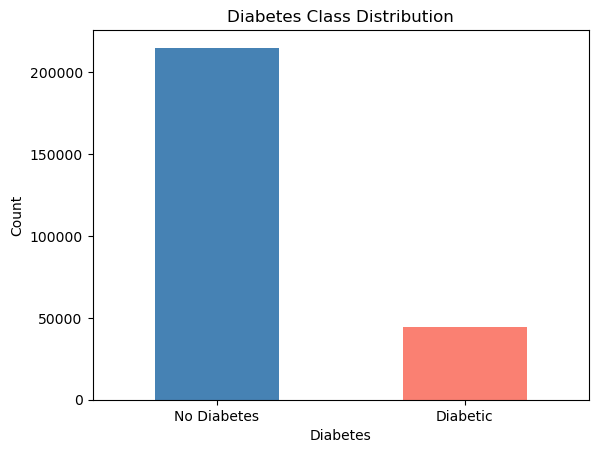

In [103]:
# ============================================================
# STEP 6 - EDA
# ============================================================


# 1. Target variable distribution
print(df['Diabetes'].value_counts())
print(df['Diabetes'].value_counts(normalize=True).mul(100).round(2))

# 2. Class imbalance plot
df['Diabetes'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Diabetes Class Distribution')
plt.xticks([0,1], ['No Diabetes',  'Diabetic'], rotation=0)
plt.ylabel('Count')
plt.show()



## STEP 7 - Boxplots for numeric variables

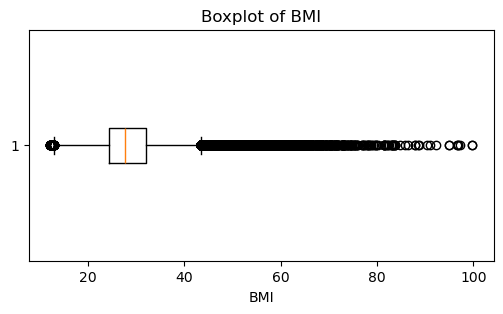

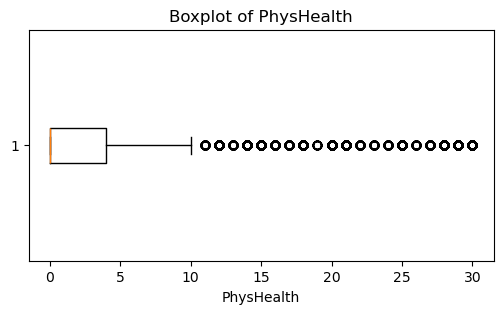

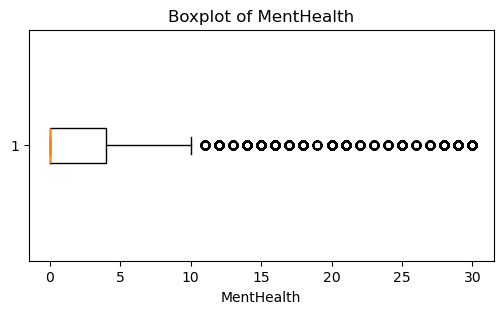

In [104]:
# ============================================================
# STEP 7 - Boxplots for numeric variables
# ============================================================
cols_for_boxplot = ["BMI", "PhysHealth", "MentHealth"]  # keep only the useful numeric ones

for col in cols_for_boxplot:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## STEP 8 - Correlation Check


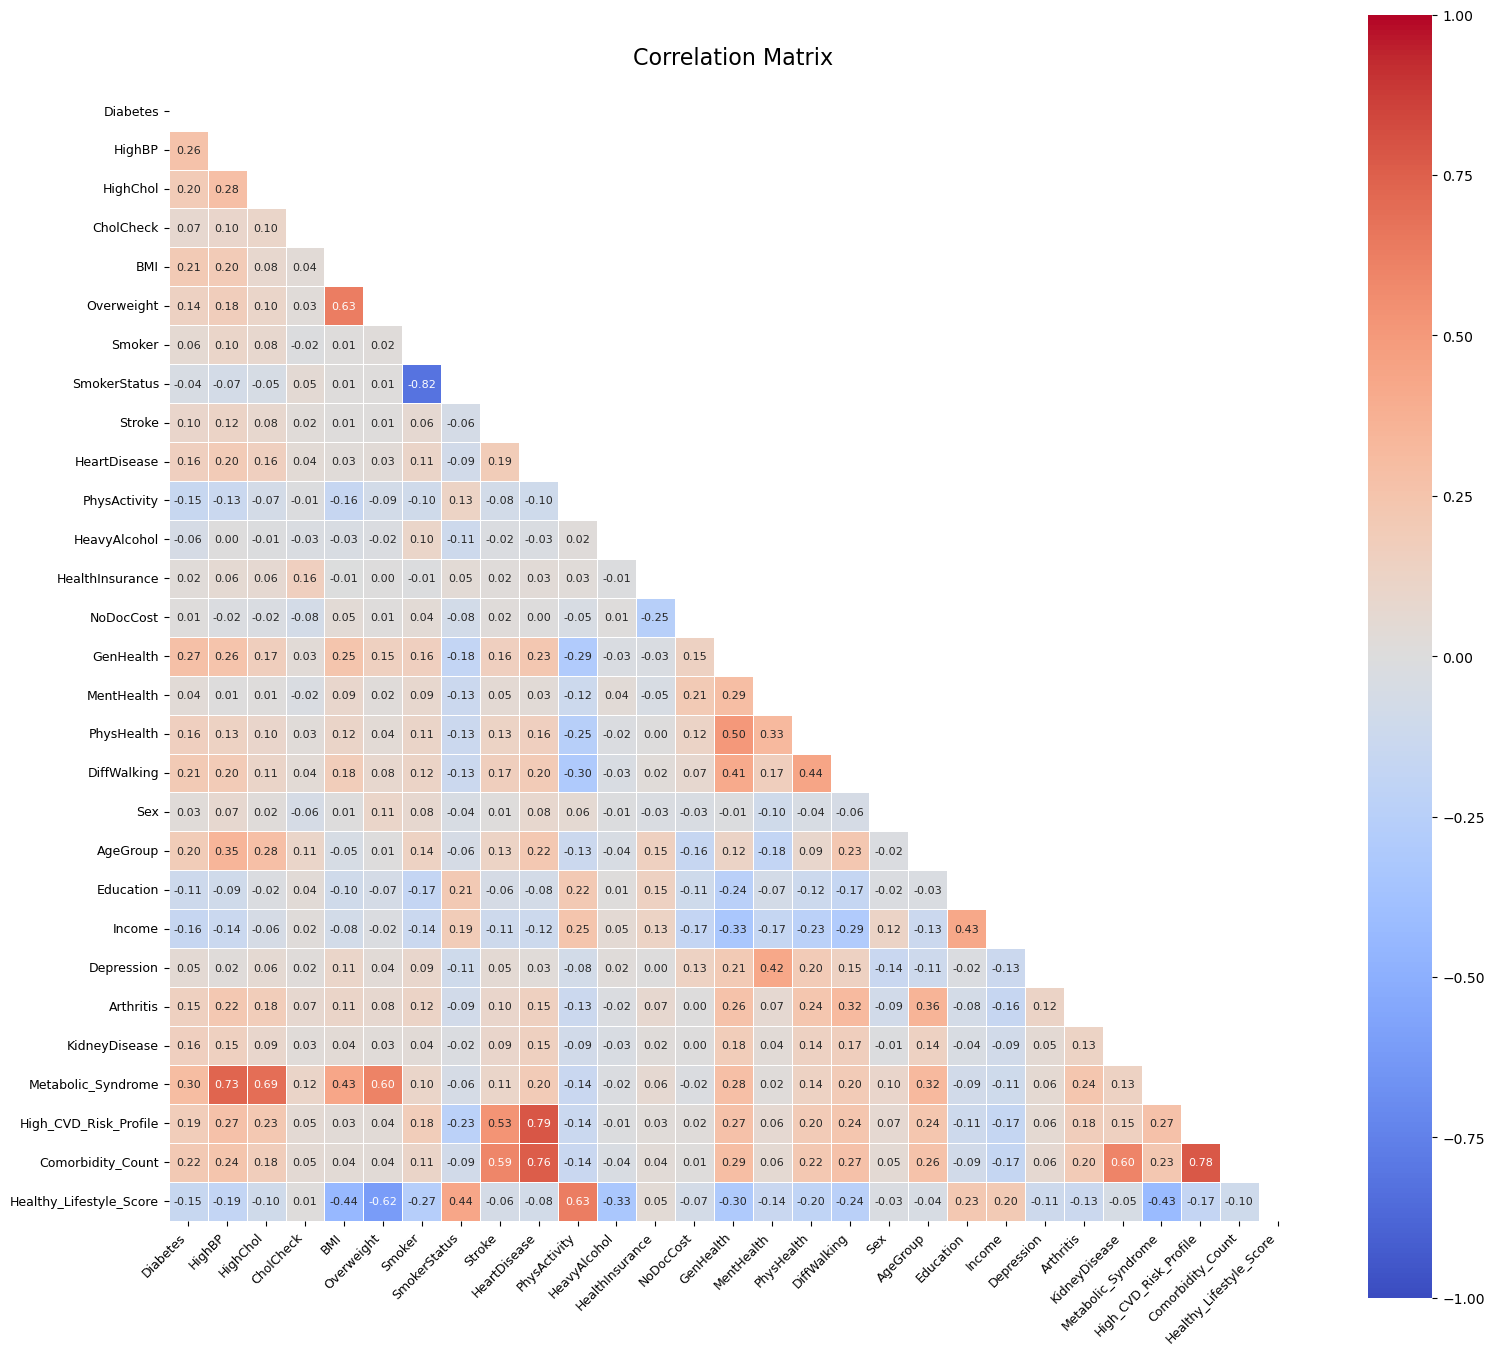

In [105]:
# ============================================================
# STEP 8 - Correlation Check
# ============================================================
#  Drop metadata columns - not needed for analysis
cols_to_drop = ['SequenceNo', 'PSU', 'State', 'QuestionnaireVersion', 'QuestionnaireLang']
df_analysis = df.drop(columns=cols_to_drop)

# Correlation matrix - cleaner version
plt.figure(figsize=(16, 14))

corr = df_analysis.corr()

# Mask upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## STEP 9 - Final Columns Selection

In [106]:
# ============================================================
# STEP 9 - Final Columns to Have
# ============================================================

target_col = ['Diabetes']
continuous_cols = ['MentHealth', 'PhysHealth', 'BMI']
ordinal_cols = ['GenHealth', 'AgeGroup', 'Education', 'Income', 'SmokerStatus', 'Metabolic_Syndrome', 'Comorbidity_Count', 'Healthy_Lifestyle_Score']
binary_cols = ['Overweight', 'HighBP', 'HighChol', 'Stroke',
               'HeartDisease', 'PhysActivity', 'HeavyAlcohol',
               'HealthInsurance', 'NoDocCost', 'DiffWalking', 'Sex', 
               'Depression', 'Arthritis', 'KidneyDisease', 'High_CVD_Risk_Profile', 'CholCheck']

feature_col = continuous_cols + ordinal_cols + binary_cols

## STEP 10 - Splitting to test and train sets

In [107]:
# ============================================================
# STEP 10 - Splitting to test and train sets
# ============================================================
X = df[feature_col]
y = df[target_col]

# Split the data into training and testing sets

X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.3, stratify = y, random_state=1)

#X_train, X_val, y_train, y_val  = train_test_split(X_train, y_train, test_size=0.25, stratify = y_train, random_state=1)

y_train = y_train.values.ravel()
#y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

print(f"Train dataframe shape: {X_train.shape}")
#print(f"Validation dataframe shape: {X_val.shape}")
print(f"Test dataframe shape: {X_test.shape}")


Train dataframe shape: (181488, 27)
Test dataframe shape: (77781, 27)


## STEP 11. Nested cross validation


In [108]:
# Function for nested cross validation

def all_pipeline(X, y, dict_of_models, hyperparameters_dict, continuous_cols,
                 cv_folds_outer=4, cv_folds_inner=4):

    # 1. Define Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), continuous_cols)],
        remainder='passthrough'
    )


    # 2. Define the metrics (Now including roc_auc)
    # Note: 'roc_auc' works for binary. For multiclass, use 'roc_auc_ovr'
    scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1_score': make_scorer(f1_score),
        'roc_auc': 'roc_auc'
    }

    results = {}

    pbar = tqdm(dict_of_models.items(), desc="Overall Progress")

    for model_name, model_obj in pbar:
        if model_name != 'Naive Bayes Complement':
          preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), continuous_cols)],
        remainder='passthrough'
                                          )
        else:
          preprocessor = ColumnTransformer(
          transformers=[('num', MinMaxScaler(), continuous_cols)],
          remainder='passthrough')

        pbar.set_description(f"Processing {model_name}")
        print(f"\n Model: {model_name}")

        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

        inner_cv = StratifiedKFold(n_splits=cv_folds_inner, shuffle=True, random_state=42)
        outer_cv = StratifiedKFold(n_splits=cv_folds_outer, shuffle=True, random_state=42)

        p_grid = hyperparameters_dict[model_name]

        # We tune the inner loop based on f1_macro or roc_auc depending on your preference
        clf = GridSearchCV(estimator=pipe, param_grid=p_grid, cv=inner_cv, scoring='f1', verbose=2) # in reality there is f1_score not f1_macro

        # Outer Loop
        cv_results = cross_validate(clf, X=X, y=y.ravel(), cv=outer_cv, scoring=scoring_metrics)

        # 3. Store and Print the Results
        results[model_name] = {
            'Model': model_name,

            'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.2f})",

            'F1_Score': f"{cv_results['test_f1_score'].mean():.4f} (+/- {cv_results['test_f1_score'].std():.2f})",

            'Recall': f"{cv_results['test_recall'].mean():.4f} (+- {cv_results['test_recall'].std():.2f})",

            'Precision': f"{cv_results['test_precision'].mean():.4f} (+0- {cv_results['test_precision'].std():.2f})",

            'AUC-ROC': f"{cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.2f})"

        }


        print(f"--- {model_name} Aggregated Report ---")
        print(f"Accuracy:  {results[model_name]['Accuracy']}")
        print(f"Precision: {results[model_name]['Precision']}")
        print(f"Recall:    {results[model_name]['Recall']}")
        print(f"F1-Score:  {results[model_name]['F1_Score']}")
        print(f"ROC-AUC:   {results[model_name]['AUC-ROC']}")

    return results

In [109]:
# All models and hyperparameters set
dict_of_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', solver='saga'),
    'Naive Bayes Gaussian': GaussianNB(),
    'Naive Bayes Complement': ComplementNB(),
    'SVM': SGDClassifier(class_weight='balanced'),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'CatBoost': CatBoostClassifier(logging_level='Silent'),
    'LightGBM': LGBMClassifier(verbosity=-1),
    'Ada Boost': AdaBoostClassifier(),
    'Gradient Boost': HistGradientBoostingClassifier(),
    'Balanced RF': BalancedRandomForestClassifier()
}

hyperparameters_dict = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 500],
        'classifier__max_depth': [3, 5, 10]
    },
    'Naive Bayes Gaussian': {
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-5]
    },
    'Naive Bayes Complement': {
        'classifier__alpha': [0.1, 1.0, 10, 0.001]
    },
    'SVM':
        {
    'classifier__loss': ['hinge', 'log_loss'],
    'classifier__alpha': [1e-4, 1e-2, 1e-1, 1]
}
    ,
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.1, 0.3, 0.5],
        'classifier__max_depth': [3, 5, 10],
        'classifier__scale_pos_weight': [2, 3, 4]
    },
    'CatBoost': {
        'classifier__iterations': [100, 200, 500],
        'classifier__depth': [4, 6],
        'classifier__scale_pos_weight': [2, 3, 4]
    },
    'Balanced RF': {
        'classifier__n_estimators': [100, 200, 500],
        'classifier__max_depth': [3, 5, 10]
    },
    'LightGBM': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.3],
        'classifier__scale_pos_weight': [2, 3, 4],
        'classifier__max_depth': [3, 5, 10]
    },
    'Ada Boost':{
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.1, 1, 5]
    },
    'Gradient Boost':{
        'classifier__max_depth': [3, 5, 10],
        'classifier__learning_rate': [0.01, 0.1, 0.3]
    }

}

In [110]:
# Running all models with hyperparameter selection and predefined nested cross validation in order to get stability of models

results = all_pipeline(X_train, y_train, dict_of_models, hyperparameters_dict, continuous_cols)


Processing Logistic Regression:   0%|                                                           | 0/10 [00:00<?, ?it/s]


 Model: Logistic Regression
Fitting 4 folds for each of 4 candidates, totalling 16 fits
[CV] END .................................classifier__C=0.01; total time=   1.2s
[CV] END .................................classifier__C=0.01; total time=   1.2s
[CV] END .................................classifier__C=0.01; total time=   1.2s
[CV] END .................................classifier__C=0.01; total time=   1.0s
[CV] END ..................................classifier__C=0.1; total time=   1.2s
[CV] END ..................................classifier__C=0.1; total time=   1.2s
[CV] END ..................................classifier__C=0.1; total time=   1.2s
[CV] END ..................................classifier__C=0.1; total time=   1.1s
[CV] END ....................................classifier__C=1; total time=   1.2s
[CV] END ....................................classifier__C=1; total time=   1.2s
[CV] END ....................................classifier__C=1; total time=   1.2s
[CV] END ...........

Processing Naive Bayes Gaussian:  10%|█████                                             | 1/10 [01:25<12:49, 85.50s/it]

--- Logistic Regression Aggregated Report ---
Accuracy:  0.7187 (+/- 0.00)
Precision: 0.3485 (+0- 0.00)
Recall:    0.7450 (+- 0.01)
F1-Score:  0.4748 (+/- 0.00)
ROC-AUC:   0.8038 (+/- 0.00)

 Model: Naive Bayes Gaussian
Fitting 4 folds for each of 3 candidates, totalling 12 fits
[CV] END ....................classifier__var_smoothing=1e-09; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-09; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-09; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-09; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-08; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-08; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-08; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-08; total time=   0.0s
[CV] END ....................classifier__var_smoothing=1e-05; total time

Processing Naive Bayes Complement:  20%|█████████▌                                      | 2/10 [01:30<05:06, 38.31s/it]

...

--- Ada Boost Aggregated Report ---
Accuracy:  0.8384 (+/- 0.00)
Precision: 0.5707 (+0- 0.00)
Recall:    0.2155 (+- 0.00)
F1-Score:  0.3128 (+/- 0.00)
ROC-AUC:   0.8063 (+/- 0.00)

 Model: Gradient Boost
Fitting 4 folds for each of 9 candidates, totalling 36 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3; total time=   2.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3; total time=   2.3s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3; total time=   2.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3; total time=   2.2s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5; total time=   2.6s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5; total time=   2.7s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5; total time=   2.7s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=5; total time=   2.7s
[CV] END classifier__learning_rate=0.01, classifier__max

Processing Balanced RF:  90%|██████████████████████████████████████████████████▍     | 9/10 [1:14:36<09:37, 577.20s/it]

--- Gradient Boost Aggregated Report ---
Accuracy:  0.8393 (+/- 0.00)
Precision: 0.5862 (+0- 0.01)
Recall:    0.1993 (+- 0.00)
F1-Score:  0.2974 (+/- 0.00)
ROC-AUC:   0.8072 (+/- 0.00)

 Model: Balanced RF
Fitting 4 folds for each of 9 candidates, totalling 36 fits
[CV] END classifier__max_depth=3, classifier__n_estimators=100; total time=   2.5s
[CV] END classifier__max_depth=3, classifier__n_estimators=100; total time=   2.7s
[CV] END classifier__max_depth=3, classifier__n_estimators=100; total time=   2.5s
[CV] END classifier__max_depth=3, classifier__n_estimators=100; total time=   2.6s
[CV] END classifier__max_depth=3, classifier__n_estimators=200; total time=   5.3s
[CV] END classifier__max_depth=3, classifier__n_estimators=200; total time=   5.4s
[CV] END classifier__max_depth=3, classifier__n_estimators=200; total time=   5.4s
[CV] END classifier__max_depth=3, classifier__n_estimators=200; total time=   5.4s
[CV] END classifier__max_depth=3, classifier__n_estimators=500; total 

Processing Balanced RF: 100%|███████████████████████████████████████████████████████| 10/10 [1:34:48<00:00, 568.84s/it]

--- Balanced RF Aggregated Report ---
Accuracy:  0.7053 (+/- 0.00)
Precision: 0.3396 (+0- 0.00)
Recall:    0.7688 (+- 0.01)
F1-Score:  0.4711 (+/- 0.00)
ROC-AUC:   0.8054 (+/- 0.00)


In [111]:
results # nested-cross validation results

{'Logistic Regression': {'Model': 'Logistic Regression',
  'Accuracy': '0.7187 (+/- 0.00)',
  'F1_Score': '0.4748 (+/- 0.00)',
  'Recall': '0.7450 (+- 0.01)',
  'Precision': '0.3485 (+0- 0.00)',
  'AUC-ROC': '0.8038 (+/- 0.00)'},
 'Naive Bayes Gaussian': {'Model': 'Naive Bayes Gaussian',
  'Accuracy': '0.7634 (+/- 0.00)',
  'F1_Score': '0.4414 (+/- 0.00)',
  'Recall': '0.5476 (+- 0.00)',
  'Precision': '0.3697 (+0- 0.00)',
  'AUC-ROC': '0.7716 (+/- 0.00)'},
 'Naive Bayes Complement': {'Model': 'Naive Bayes Complement',
  'Accuracy': '0.7317 (+/- 0.00)',
  'F1_Score': '0.4444 (+/- 0.00)',
  'Recall': '0.6287 (+- 0.00)',
  'Precision': '0.3437 (+0- 0.00)',
  'AUC-ROC': '0.7693 (+/- 0.00)'},
 'SVM': {'Model': 'SVM',
  'Accuracy': '0.7222 (+/- 0.01)',
  'F1_Score': '0.4741 (+/- 0.01)',
  'Recall': '0.7332 (+- 0.02)',
  'Precision': '0.3506 (+0- 0.01)',
  'AUC-ROC': '0.8023 (+/- 0.00)'},
 'XGBoost': {'Model': 'XGBoost',
  'Accuracy': '0.7796 (+/- 0.00)',
  'F1_Score': '0.4904 (+/- 0.01)',
 

In [112]:
new_results = results.copy()

nested_df = pd.DataFrame.from_dict(new_results, orient='index')

#nested_df = nested_df.rename(columns={'F1_Macro': 'F1-score'})

nested_df['temp_sort'] = nested_df['F1_Score'].str[:6].astype(float)
nested_df_sorted = nested_df.sort_values('temp_sort', ascending=False).drop(columns=['temp_sort'])

styled_df = (nested_df_sorted.style
             .set_caption("Model Performance Comparison")
             .hide(axis='index')
             .set_properties(**{'text-align': 'center', 'border': '1px solid white'})
             .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white')]}]))

display(styled_df) # Stability of the models on nested-cross validation

Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
LightGBM,0.7796 (+/- 0.00),0.4906 (+/- 0.00),0.6217 (+- 0.01),0.4052 (+0- 0.00),0.8095 (+/- 0.00)
XGBoost,0.7796 (+/- 0.00),0.4904 (+/- 0.01),0.6214 (+- 0.01),0.4051 (+0- 0.00),0.8098 (+/- 0.00)
CatBoost,0.7801 (+/- 0.00),0.4897 (+/- 0.00),0.6180 (+- 0.00),0.4054 (+0- 0.00),0.8091 (+/- 0.00)
Logistic Regression,0.7187 (+/- 0.00),0.4748 (+/- 0.00),0.7450 (+- 0.01),0.3485 (+0- 0.00),0.8038 (+/- 0.00)
SVM,0.7222 (+/- 0.01),0.4741 (+/- 0.01),0.7332 (+- 0.02),0.3506 (+0- 0.01),0.8023 (+/- 0.00)
Balanced RF,0.7053 (+/- 0.00),0.4711 (+/- 0.00),0.7688 (+- 0.01),0.3396 (+0- 0.00),0.8054 (+/- 0.00)
Naive Bayes Complement,0.7317 (+/- 0.00),0.4444 (+/- 0.00),0.6287 (+- 0.00),0.3437 (+0- 0.00),0.7693 (+/- 0.00)
Naive Bayes Gaussian,0.7634 (+/- 0.00),0.4414 (+/- 0.00),0.5476 (+- 0.00),0.3697 (+0- 0.00),0.7716 (+/- 0.00)
Ada Boost,0.8384 (+/- 0.00),0.3128 (+/- 0.00),0.2155 (+- 0.00),0.5707 (+0- 0.00),0.8063 (+/- 0.00)
Gradient Boost,0.8393 (+/- 0.00),0.2974 (+/- 0.00),0.1993 (+- 0.00),0.5862 (+0- 0.01),0.8072 (+/- 0.00)


In [113]:
nested_df = pd.DataFrame.from_dict(results, orient='index')

#nested_df = nested_df.rename(columns={'F1_Macro': 'F1-score'})


for col in ['F1_Score', 'Precision', 'Recall', 'Accuracy', 'AUC-ROC']:
    nested_df[col] = nested_df[col].str[:6].astype(float)

nested_df_sorted = nested_df.sort_values('F1_Score', ascending=False)


# The same nested cross validation table but in more beatiful format
display(nested_df_sorted.style.background_gradient(cmap='Blues').format("{:.4f}", subset=nested_df.columns[1:]).hide(axis='index'))

Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
LightGBM,0.7796,0.4906,0.6217,0.4052,0.8095
XGBoost,0.7796,0.4904,0.6214,0.4051,0.8098
CatBoost,0.7801,0.4897,0.6180,0.4054,0.8091
Logistic Regression,0.7187,0.4748,0.7450,0.3485,0.8038
SVM,0.7222,0.4741,0.7332,0.3506,0.8023
Balanced RF,0.7053,0.4711,0.7688,0.3396,0.8054
Naive Bayes Complement,0.7317,0.4444,0.6287,0.3437,0.7693
Naive Bayes Gaussian,0.7634,0.4414,0.5476,0.3697,0.7716
Ada Boost,0.8384,0.3128,0.2155,0.5707,0.8063
Gradient Boost,0.8393,0.2974,0.1993,0.5862,0.8072


## STEP 12. Selecting the best hyperparameters for all models

In [114]:
# picking the best hyperparameters for all models

def get_best_hyperparameters_for_all(X, y, dict_of_models, hyperparameters_dict, continuous_cols):
    """
    Fits every model on the full provided dataset to find the
    absolute best hyperparameter sets.
    """
    best_params_report = {}
    best_estimators = {}

    print("🏁 Starting Global Hyperparameter Optimization...")

    for model_name, model_obj in dict_of_models.items():
        print(f"\n🔍 Tuning {model_name}...")

        if model_name == 'Naive Bayes Complement':
            scaler = MinMaxScaler()
        else:
            scaler = StandardScaler()

        preprocessor = ColumnTransformer(
            transformers=[('num', scaler, continuous_cols)],
            remainder='passthrough'
        )

        # 2. Build Pipeline
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

        # Run GridSearchCV on the WHOLE dataset

        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=hyperparameters_dict[model_name],
            cv=5,
            scoring='f1',
            #n_jobs=2,
            verbose=1
        )


        grid_search.fit(X, y.ravel())



        best_params_report[model_name] = grid_search.best_params_
        best_estimators[model_name] = grid_search.best_estimator_

        print(f"✅ Best for {model_name}: {grid_search.best_params_}")
        print(f"📈 Best F1 score: {grid_search.best_score_:.4f}")


    return best_params_report, best_estimators

# Dictionary of params and the actual trained models
absolute_best_params, trained_models = get_best_hyperparameters_for_all(
    X_train, y_train, dict_of_models, hyperparameters_dict, continuous_cols
)

🏁 Starting Global Hyperparameter Optimization...

🔍 Tuning Logistic Regression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
✅ Best for Logistic Regression: {'classifier__C': 0.01}
📈 Best F1 score: 0.4747

🔍 Tuning Naive Bayes Gaussian...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
✅ Best for Naive Bayes Gaussian: {'classifier__var_smoothing': 1e-05}
📈 Best F1 score: 0.4412

🔍 Tuning Naive Bayes Complement...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
✅ Best for Naive Bayes Complement: {'classifier__alpha': 10}
📈 Best F1 score: 0.4443

🔍 Tuning SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best for SVM: {'classifier__alpha': 0.0001, 'classifier__loss': 'log_loss'}
📈 Best F1 score: 0.4793

🔍 Tuning XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best for XGBoost: {'classifier__learning_rate': 0.3, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight':

## STEP 13. Checking THE STABILITY ON THE OVERALL TRAINING DATASET

In [115]:
# AS WE GOT BEST HYPERPARAMETERS ON OUR DATA -> NEEDS TO CHECK THE STABILITY ON THE OVERALL TRAINING DATASET
from tqdm import tqdm

final_results = {}


log_reg_model = LogisticRegression(class_weight='balanced', solver='saga', C= 0.01)
nb_gaussian_model = GaussianNB(var_smoothing = 1e-05)
nb_complement_model = ComplementNB(alpha = 10)
svm_model = SGDClassifier(class_weight='balanced', alpha = 0.0001, loss = 'log_loss')
xgboost_model = XGBClassifier(eval_metric='logloss', learning_rate = 0.3, max_depth = 3, n_estimators = 100, scale_pos_weight = 3)
catboost_model = CatBoostClassifier(logging_level='Silent', depth = 4, iterations = 500, scale_pos_weight = 3)
lightgbm_model = LGBMClassifier(verbosity=-1, learning_rate = 0.1, max_depth = 3, n_estimators = 200, scale_pos_weight = 3)
adaboost_model = AdaBoostClassifier(learning_rate = 1, n_estimators = 50)
gradient_boost_model = HistGradientBoostingClassifier(learning_rate = 0.3, max_depth = 10)
balanced_rf_model = BalancedRandomForestClassifier(max_depth = 10, n_estimators = 500)

scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),# average='macro'),
        'recall': make_scorer(recall_score),# average='macro'),
        'f1_score': make_scorer(f1_score),# average='macro'),
        'roc_auc': 'roc_auc'
    }

model_list = [log_reg_model, nb_gaussian_model, nb_complement_model, svm_model, xgboost_model, catboost_model, lightgbm_model, adaboost_model, gradient_boost_model, balanced_rf_model]

dict_models = {'Logistic Regression' : log_reg_model,
               'NB Gaussian': nb_gaussian_model,
               'NB Complement': nb_complement_model,
               'SVM': svm_model,
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'ADABoost': adaboost_model,
               'Gradient Boosting': gradient_boost_model,
               'Balanced RF': balanced_rf_model}

pbar = tqdm(dict_models.items(), desc="Overall Progress")

for model_name, model_obj in pbar:

    if model_name == 'NB Complement':
          scaler = MinMaxScaler()
    else:
          scaler = StandardScaler()

    preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )

    pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model_obj)
        ])

    cv_results = cross_validate(pipe, X=X_train, y=y_train.ravel(), cv=5, scoring=scoring_metrics)

    final_results[model_name] = {

            'Model': model_name,

            'Accuracy': cv_results['test_accuracy'],

            'F1_Score': cv_results['test_f1_score'],

            'Recall': cv_results['test_recall'],

            'Precision': cv_results['test_precision'],

            'AUC-ROC': cv_results['test_roc_auc']

    }


final_results_df = pd.DataFrame.from_dict(final_results, orient='index')

metrics_cols = ['Accuracy', 'F1_Score', 'Recall', 'Precision', 'AUC-ROC']

for col in metrics_cols:
    final_results_df[col] = final_results_df[col].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)

final_results_df_sorted = final_results_df.sort_values('F1_Score', ascending=False)

display(
    final_results_df_sorted.style
    .background_gradient(cmap='Blues', subset=metrics_cols)
    .format("{:.4f}", subset=metrics_cols)
    .hide(axis='index')
)

# RESULTS OF THE ALL MODELS ON TRAINING SETS

Overall Progress: 100%|████████████████████████████████████████████████████████████████| 10/10 [04:29<00:00, 26.93s/it]


Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
LightGBM,0.7813,0.4919,0.6203,0.4076,0.8103
XGBoost,0.7806,0.4918,0.6219,0.4067,0.8101
Catboost,0.7808,0.4909,0.6192,0.4067,0.8101
Logistic Regression,0.7185,0.4747,0.7449,0.3483,0.8038
SVM,0.7703,0.4728,0.6084,0.3986,0.8024
Balanced RF,0.7051,0.4712,0.7697,0.3396,0.8057
NB Complement,0.7318,0.4443,0.6283,0.3437,0.7693
NB Gaussian,0.7635,0.4412,0.5470,0.3697,0.7716
ADABoost,0.8384,0.3106,0.2134,0.5709,0.8058
Gradient Boosting,0.8393,0.2985,0.2004,0.5854,0.8075


## STEP 14. SHAP VALUES FOR MODELS

## Features that have the most impact on diabete prediction

--- Processing XGBoost ---


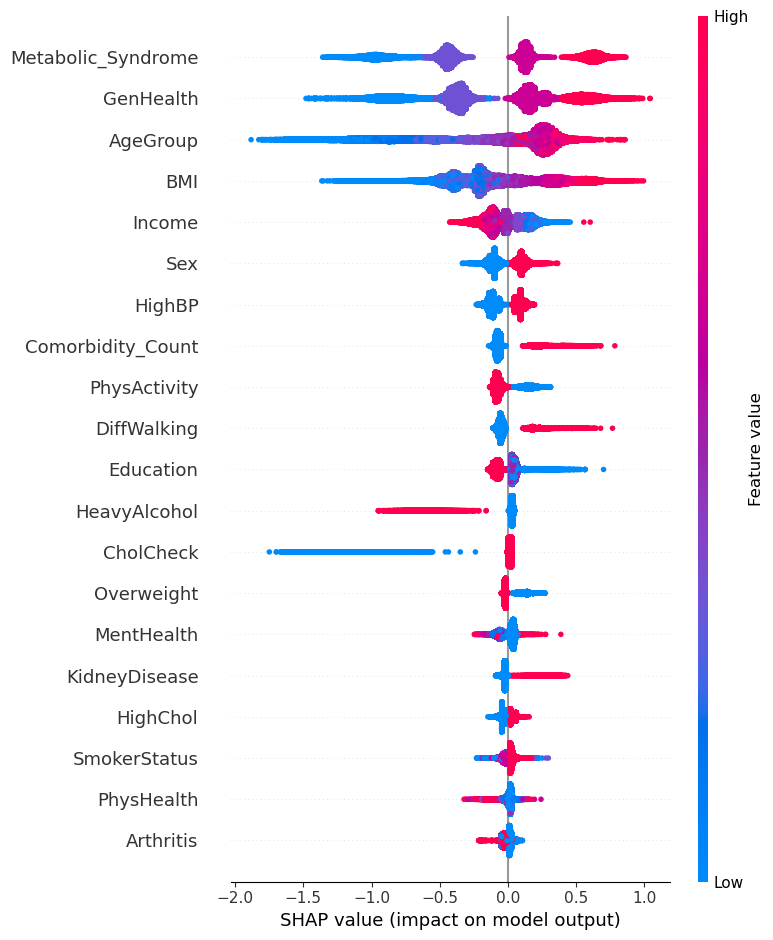

--- Processing Catboost ---


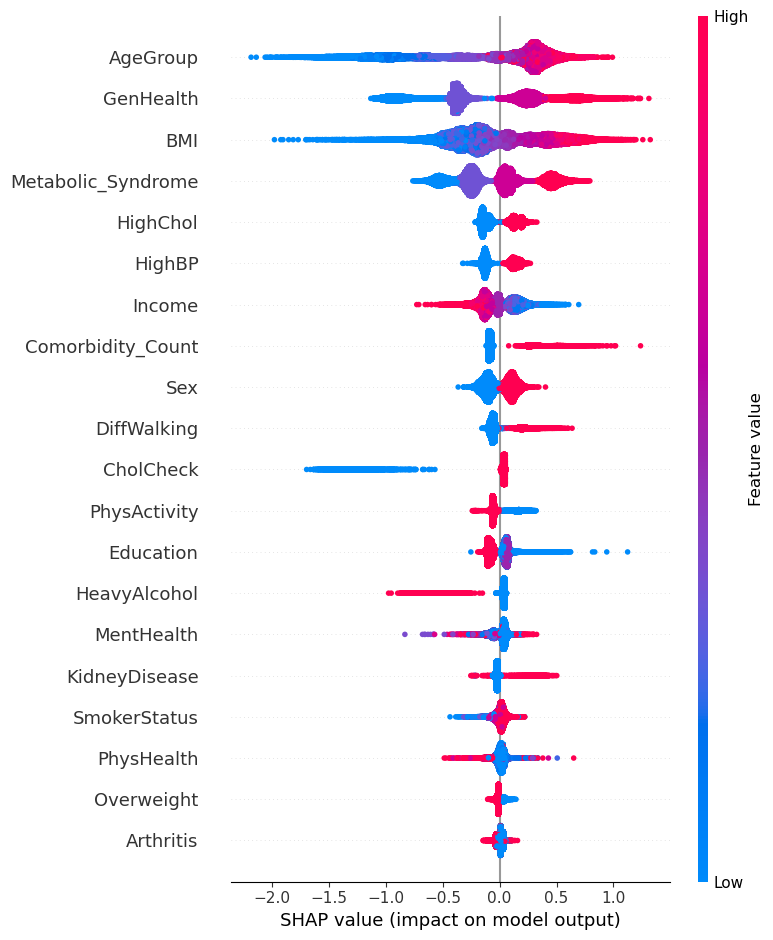

--- Processing LightGBM ---


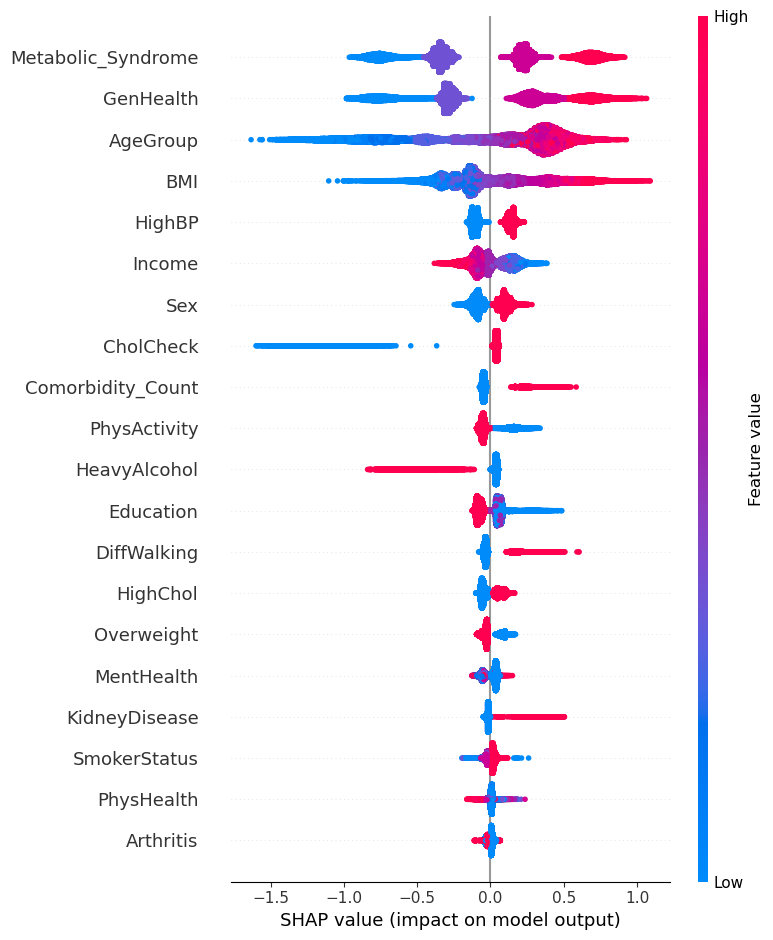

--- Processing BalancedRF ---


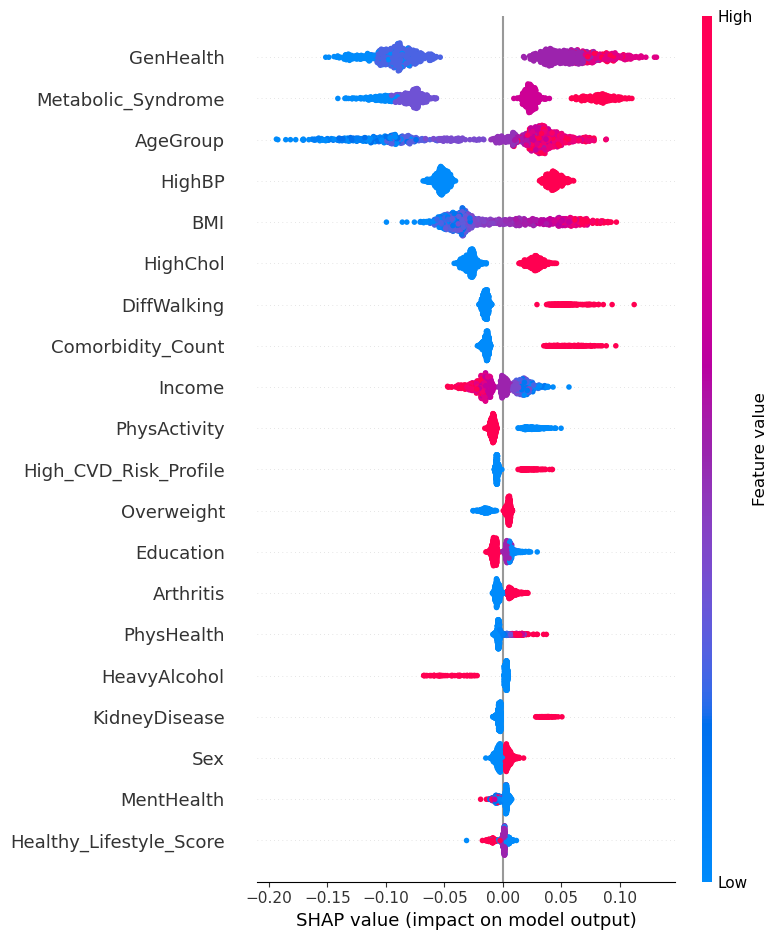

--- Processing Gradient Boosting ---


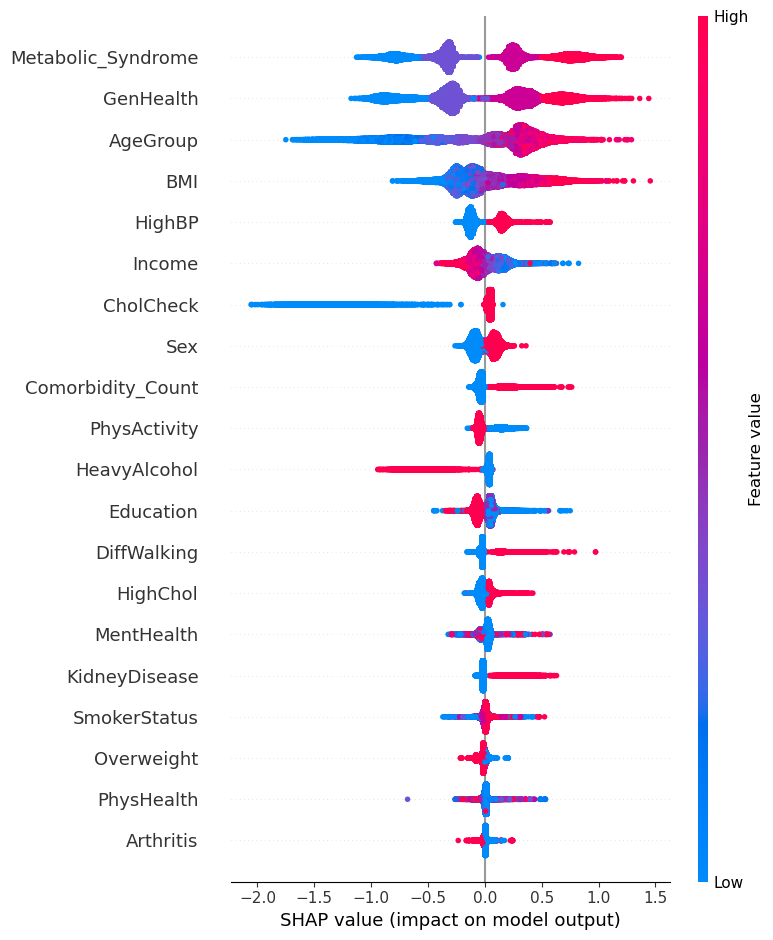

In [116]:
# shap values for TREE-BASED MODELS

dict_shap_models = {
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'BalancedRF': balanced_rf_model,
               'Gradient Boosting': gradient_boost_model
               }


for name, model in dict_shap_models.items():
    print(f"--- Processing {name} ---")

    X_train_copy = X_train.copy()

    X_test_copy = X_test.copy()

    scaler = StandardScaler()

    X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
    X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

    model.fit(X_train_copy, y_train)

    if name == 'BalancedRF':
      X_test_sample = shap.sample(X_test_copy, 1000)
    else:
      X_test_sample = X_test_copy
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test_sample)

    if isinstance(shap_values, list):
        current_shap = shap_values[1]
    elif len(shap_values.shape) == 3:
        current_shap = shap_values[:, :, 1]
    else:
        current_shap = shap_values

    shap.summary_plot(current_shap, X_test_sample)

--- Processing Logistic Regression ---


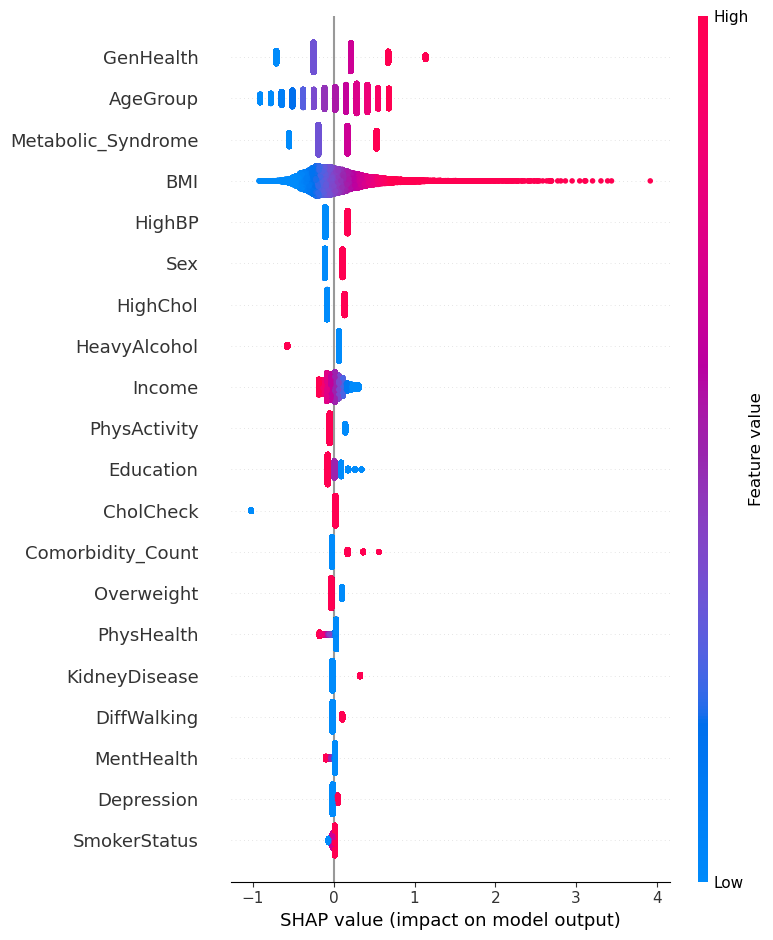

--- Processing SVM ---


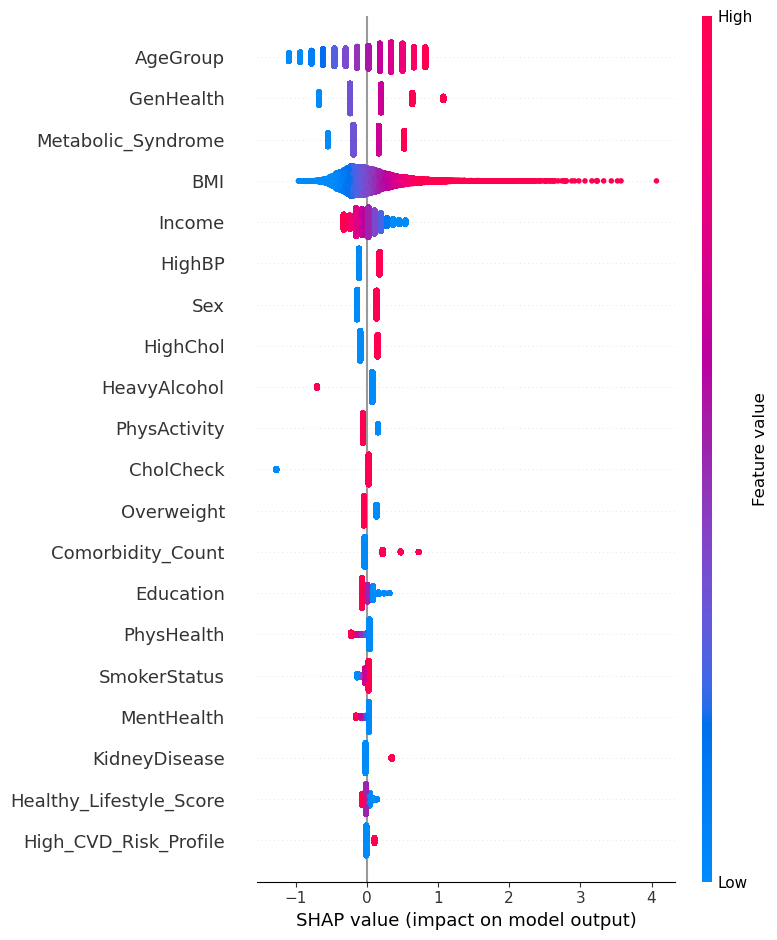

In [117]:
# shap values for Linear-BASED MODELS

dict_linear_shap_models = {
               'Logistic Regression': log_reg_model,
               'SVM': svm_model
               }

for name, model in dict_linear_shap_models.items():
    print(f"--- Processing {name} ---")

    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    scaler = StandardScaler()
    X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
    X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

    model.fit(X_train_copy, y_train)

    explainer = shap.LinearExplainer(model, X_train_copy)

    shap_values = explainer.shap_values(X_test_copy)

    current_shap = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(current_shap, X_test_copy)

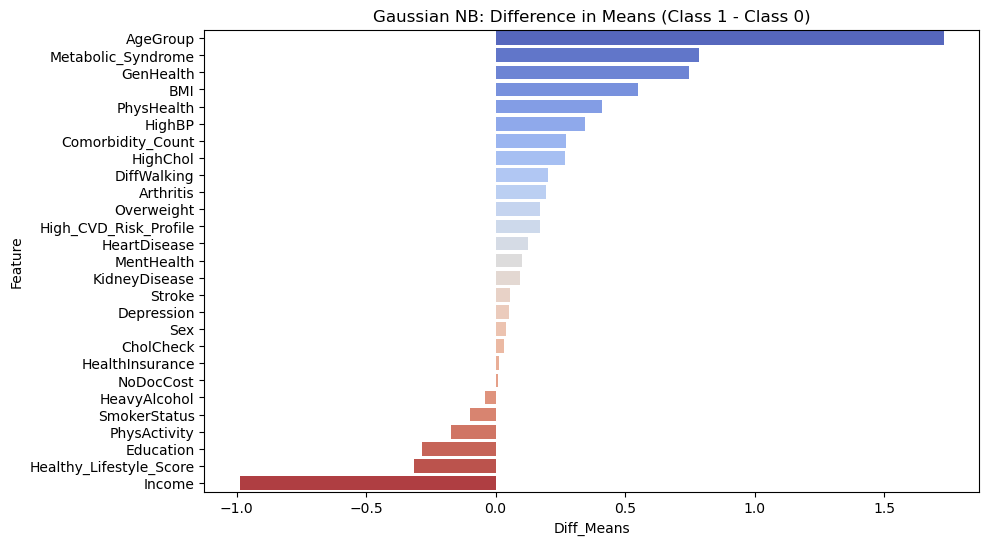

In [118]:
# GaussianNB
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

scaler = StandardScaler()
X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])

nb_gaussian_model.fit(X_train_copy, y_train)

feature_names = X_train_copy.columns
diff_means = nb_gaussian_model.theta_[1] - nb_gaussian_model.theta_[0]

feat_importance_nb = pd.DataFrame({'Feature': feature_names, 'Diff_Means': diff_means})
feat_importance_nb = feat_importance_nb.sort_values(by='Diff_Means', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Diff_Means', y='Feature', data=feat_importance_nb, palette='coolwarm')
plt.title('Gaussian NB: Difference in Means (Class 1 - Class 0)')
plt.show()

THE LEAST LOGPROB VALUE THE LEAST IMPORTANT FEATURE

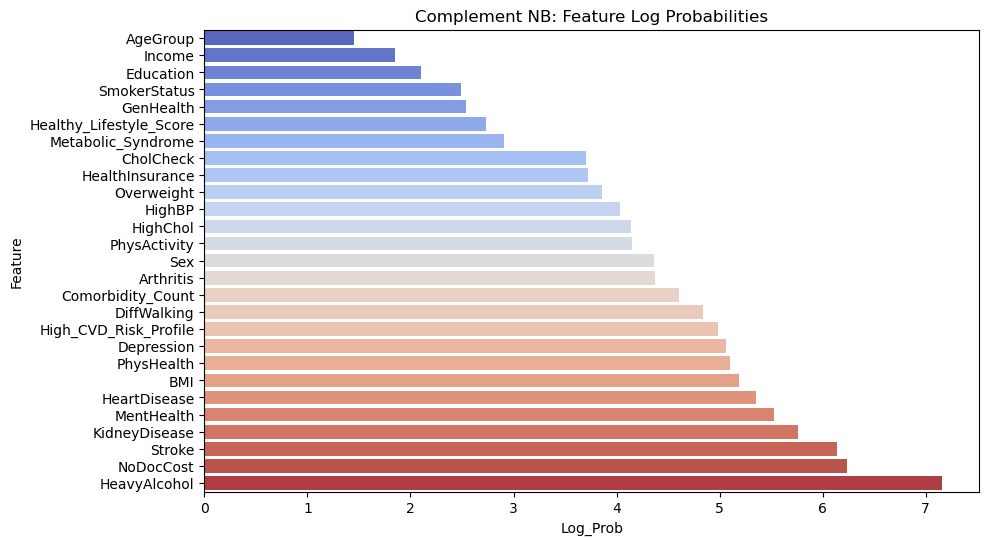

In [119]:
# ComplementNB


X_train_copy = X_train.copy()
X_test_copy = X_test.copy()


scaler = MinMaxScaler()
X_train_copy[continuous_cols] = scaler.fit_transform(X_train_copy[continuous_cols])
X_test_copy[continuous_cols] = scaler.transform(X_test_copy[continuous_cols])


nb_complement_model.fit(X_train_copy, y_train)

importance_cnb = nb_complement_model.feature_log_prob_[0]

feat_importance_cnb = pd.DataFrame({'Feature': feature_names, 'Log_Prob': importance_cnb})
feat_importance_cnb = feat_importance_cnb.sort_values(by='Log_Prob', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Log_Prob', y='Feature', data=feat_importance_cnb, palette='coolwarm')
plt.title('Complement NB: Feature Log Probabilities')
plt.show()

## STEP 15. SOFT AND HARD VOTING (ENSEMBLING OF THE MODELS)

In [120]:
 # DO SOFT/HARD VOTING

scoring_metrics_new = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1_score': make_scorer(f1_score)
    }


estimators=[('brf', balanced_rf_model),  ('svm', svm_model), ('lightgbm', lightgbm_model), ('catboost', catboost_model), ('logreg', log_reg_model), ('xgboost', xgboost_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='soft')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

voting_soft_results = cross_validate(
    pipe, X_train, y_train.ravel(),
    cv=5,
    scoring=scoring_metrics_new
)

voting_soft_results

{'fit_time': array([41.29100299, 42.47954416, 40.34004092, 39.63458061, 39.61386323]),
 'score_time': array([1.6701498 , 1.6223259 , 1.83246899, 1.74124861, 1.66407824]),
 'test_accuracy': array([0.76307235, 0.7375613 , 0.73670726, 0.7393173 , 0.74873957]),
 'test_precision': array([0.38653955, 0.36417034, 0.36382789, 0.36653321, 0.37492517]),
 'test_recall': array([0.66091026, 0.72046482, 0.72466107, 0.72413236, 0.70766747]),
 'test_f1_score': array([0.48779035, 0.48379755, 0.48443653, 0.48670934, 0.490161  ])}

FINAL RESULTS FOR SOFT VOTING ENSEMBLE

In [121]:
voting_soft_df = pd.DataFrame({
    'Accuracy': voting_soft_results['test_accuracy'],
    'Precision': voting_soft_results['test_precision'],
    'Recall': voting_soft_results['test_recall'],
    'F1-score': voting_soft_results['test_f1_score']
})

# Настройка индекса
voting_soft_df.index = [f"Fold {i+1}" for i in range(len(voting_soft_df))]

# Добавление средней строки
voting_soft_df.loc['AVERAGE'] = voting_soft_df.mean()
voting_soft_df

,Accuracy,Precision,Recall,F1-score
Fold 1,0.763072,0.386540,0.660910,0.487790
Fold 2,0.737561,0.364170,0.720465,0.483798
Fold 3,0.736707,0.363828,0.724661,0.484437
Fold 4,0.739317,0.366533,0.724132,0.486709
Fold 5,0.748740,0.374925,0.707667,0.490161
AVERAGE,0.745080,0.371199,0.707567,0.486579


FINAL RESULTS FOR HARD VOTING ENSEMBLE

In [122]:
 # HARD VOTING

scoring_metrics_new = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),# average='macro'),
        'recall': make_scorer(recall_score),# average='macro'),
        'f1_score': make_scorer(f1_score),# average='macro')
    }


estimators=[('brf', balanced_rf_model),  ('svm', svm_model), ('lightgbm', lightgbm_model), ('catboost', catboost_model), ('logreg', log_reg_model), ('xgboost', xgboost_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='hard')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])

voting_hard_results = cross_validate(
    pipe, X_train, y_train.ravel(),
    cv=5,
    scoring=scoring_metrics_new
)

voting_hard_results



{'fit_time': array([41.91503143, 41.00594187, 39.8282342 , 39.82774258, 40.2549386 ]),
 'score_time': array([1.9046042 , 1.86410308, 1.84287262, 1.87206531, 1.85740614]),
 'test_accuracy': array([0.77425753, 0.77064852, 0.77169541, 0.7816073 , 0.77452682]),
 'test_precision': array([0.39896845, 0.39402688, 0.39608389, 0.40964107, 0.40071878]),
 'test_recall': array([0.6367011 , 0.63879923, 0.64315688, 0.63373688, 0.64794189]),
 'test_f1_score': array([0.49054961, 0.48740841, 0.49025035, 0.49762342, 0.49518875])}

RESULTS OF HARD VOTING ENSEMBLE

In [123]:
voting_hard_df = pd.DataFrame({
    'Accuracy': voting_hard_results['test_accuracy'],
    'Precision': voting_hard_results['test_precision'],
    'Recall': voting_hard_results['test_recall'],
    'F1-score': voting_hard_results['test_f1_score']
})

# Настройка индекса
voting_hard_df.index = [f"Fold {i+1}" for i in range(len(voting_hard_df))]

# Добавление средней строки
voting_hard_df.loc['AVERAGE'] = voting_hard_df.mean()
voting_hard_df

,Accuracy,Precision,Recall,F1-score
Fold 1,0.774258,0.398968,0.636701,0.490550
Fold 2,0.770649,0.394027,0.638799,0.487408
Fold 3,0.771695,0.396084,0.643157,0.490250
Fold 4,0.781607,0.409641,0.633737,0.497623
Fold 5,0.774527,0.400719,0.647942,0.495189
AVERAGE,0.774547,0.399888,0.640067,0.492204


##

## STEP 16. FINAL PREDICTION AND METRICS ON THE TEST

In [124]:
## PREDICTION FOR SOFT VOTING

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


estimators=[('brf', balanced_rf_model),  ('svm', svm_model), ('lightgbm', lightgbm_model), ('catboost', catboost_model), ('logreg', log_reg_model), ('xgboost', xgboost_model)]

ensemble = VotingClassifier(estimators=estimators,  voting='soft')

preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', ensemble)
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_probs = pipe.predict_proba(X_test)[:, 1]

# 2. Собираем метрики в словарь
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Precision_macro', 'Recall_macro', 'F1 Score_macro'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),#average='macro'),
        recall_score(y_test, y_pred),# average='macro'),
        f1_score(y_test, y_pred),# average='macro'),
        roc_auc_score(y_test, y_probs),
        precision_score(y_test, y_pred,average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
            ]
}

# 3. Превращаем в красивую таблицу
test_results_df = pd.DataFrame(metrics_data)

# Визуализация
print("--- Final Test Results ---")
display(test_results_df.style.format({"Value": "{:.4f}"})
        .background_gradient(cmap='Blues', subset=['Value']))

--- Final Test Results ---


,Metric,Value
0,Accuracy,0.7428
1,Precision,0.3688
2,Recall,0.7127
3,F1 Score,0.4861
4,AUC-ROC,0.8077
5,Precision_macro,0.6478
6,Recall_macro,0.7308
7,F1 Score_macro,0.6573


BEST MODEL (BALANCED RANDOM FOREST MODEL) IN TERMS OF RECALL AND ITS RESULTS

In [125]:
preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_rf_model)
])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_probs = pipe.predict_proba(X_test)[:, 1]

# 2. Собираем метрики в словарь
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Precision_macro', 'Recall_macro', 'F1 Score_macro'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),#average='macro'),
        recall_score(y_test, y_pred),# average='macro'),
        f1_score(y_test, y_pred),# average='macro'),
        roc_auc_score(y_test, y_probs),
        precision_score(y_test, y_pred,average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
            ]
}

# 3. Превращаем в красивую таблицу
test_results_df = pd.DataFrame(metrics_data)

# Визуализация
print("--- Final Test Results ---")
display(test_results_df.style.format({"Value": "{:.4f}"})
        .background_gradient(cmap='Blues', subset=['Value']))

--- Final Test Results ---


,Metric,Value
0,Accuracy,0.7037
1,Precision,0.3384
2,Recall,0.7703
3,F1 Score,0.4702
4,AUC-ROC,0.8035
5,Precision_macro,0.6371
6,Recall_macro,0.7301
7,F1 Score_macro,0.6322


## STEP A. RUNNING ALL MODELS WITH BEST HYPERPARAMETERS USING OVER AND UNDERSAMPLING WITH CROSS-VALIDATION

### UNDERSAMPLING. PART 1. STABILITY CHECK

(AS WE SEE THE RESULTS ARE WORSE THAN WITHOUT UNDERSAMPLING)

In [126]:
from imblearn.pipeline import Pipeline
from tqdm import tqdm
# AS WE GOT BEST HYPERPARAMETERS ON OUR DATA -> NEEDS TO CHECK THE STABILITY ON THE OVERALL TRAINING DATASET


final_results = {}

# REDEFINING THESE MODELS AND DROPPING class_weight='balanced' because we oversample and unversample
xgboost_model = XGBClassifier(eval_metric='logloss', learning_rate = 0.3, max_depth = 3, n_estimators = 100)
catboost_model = CatBoostClassifier(logging_level='Silent', depth = 4, iterations = 500)
lightgbm_model = LGBMClassifier(verbosity=-1, learning_rate = 0.1, max_depth = 3, n_estimators = 200)
log_reg_model = LogisticRegression(solver='saga', C= 0.01)
svm_model = SGDClassifier(alpha = 0.0001, loss = 'log_loss')

model_list = [log_reg_model, nb_gaussian_model, nb_complement_model, svm_model, xgboost_model, catboost_model, lightgbm_model, adaboost_model, gradient_boost_model, balanced_rf_model]

dict_models = {'Logistic Regression' : log_reg_model,
               'NB Gaussian': nb_gaussian_model,
               'NB Complement': nb_complement_model,
               'SVM': svm_model,
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'ADABoost': adaboost_model,
               'Gradient Boosting': gradient_boost_model,
               'Balanced RF': balanced_rf_model}

pbar = tqdm(dict_models.items(), desc="Overall Progress")

for model_name, model_obj in pbar:

    if model_name == 'NB Complement':
          scaler = MinMaxScaler()
    else:
          scaler = StandardScaler()

    preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )

    pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('sampling', NearMiss(version = 3)),
            ('classifier', model_obj)
        ])

    cv_results = cross_validate(pipe, X=X_train, y=y_train.ravel(), cv=5, scoring=scoring_metrics)

    final_results[model_name] = {

            'Model': model_name,

            'Accuracy': cv_results['test_accuracy'],

            'F1_Score': cv_results['test_f1_score'],

            'Recall': cv_results['test_recall'],

            'Precision': cv_results['test_precision'],

            'AUC-ROC': cv_results['test_roc_auc']

    }


final_results_df = pd.DataFrame.from_dict(final_results, orient='index')

metrics_cols = ['Accuracy', 'F1_Score', 'Recall', 'Precision', 'AUC-ROC']

for col in metrics_cols:
    final_results_df[col] = final_results_df[col].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)

final_results_df_sorted = final_results_df.sort_values('F1_Score', ascending=False)

display(
    final_results_df_sorted.style
    .background_gradient(cmap='Blues', subset=metrics_cols)
    .format("{:.4f}", subset=metrics_cols)
    .hide(axis='index')
)

# RESULTS OF THE ALL MODELS ON TRAINING SETS

Overall Progress: 100%|████████████████████████████████████████████████████████████████| 10/10 [06:45<00:00, 40.55s/it]


Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
Logistic Regression,0.6838,0.4040,0.6279,0.2978,0.7199
NB Gaussian,0.6409,0.3987,0.6974,0.2791,0.7186
NB Complement,0.6845,0.3972,0.6090,0.2948,0.7127
ADABoost,0.6549,0.3821,0.6251,0.2751,0.6945
LightGBM,0.5681,0.3332,0.6322,0.2262,0.6341
XGBoost,0.5541,0.3258,0.6313,0.2196,0.6209
Balanced RF,0.5649,0.3222,0.6059,0.2195,0.6162
Catboost,0.5421,0.3166,0.6213,0.2124,0.6017
Gradient Boosting,0.5524,0.3140,0.6002,0.2126,0.5915
SVM,0.7007,0.2672,0.4185,0.3702,0.7083


### OVERSAMPLING

In [127]:
from imblearn.pipeline import Pipeline
from tqdm import tqdm

final_results = {}

scoring_metrics = {
        'accuracy': 'accuracy',
        'precision': make_scorer(precision_score),# average='macro'),
        'recall': make_scorer(recall_score),# average='macro'),
        'f1_score': make_scorer(f1_score),# average='macro'),
        'roc_auc': 'roc_auc'
    }



model_list = [log_reg_model, nb_gaussian_model, nb_complement_model, svm_model, xgboost_model, catboost_model, lightgbm_model, adaboost_model, gradient_boost_model, balanced_rf_model]

dict_models = {'Logistic Regression' : log_reg_model,
               'NB Gaussian': nb_gaussian_model,
               'NB Complement': nb_complement_model,
               'SVM': svm_model,
               'XGBoost': xgboost_model,
               'Catboost': catboost_model,
               'LightGBM': lightgbm_model,
               'ADABoost': adaboost_model,
               'Gradient Boosting': gradient_boost_model,
               'Balanced RF': balanced_rf_model
               }

pbar = tqdm(dict_models.items(), desc="Overall Progress")

for model_name, model_obj in pbar:

    if model_name == 'NB Complement':
          scaler = MinMaxScaler()
    else:
          scaler = StandardScaler()

    preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )

    pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
              ('resampler', SMOTEENN(random_state=42)),
            ('classifier', model_obj)
        ])

    cv_results = cross_validate(pipe, X=X_train, y=y_train.ravel(), cv=2, scoring=scoring_metrics)

    final_results[model_name] = {

            'Model': model_name,

            'Accuracy': cv_results['test_accuracy'],

            'F1_Score': cv_results['test_f1_score'],

            'Recall': cv_results['test_recall'],

            'Precision': cv_results['test_precision'],

            'AUC-ROC': cv_results['test_roc_auc']

    }


final_results_df = pd.DataFrame.from_dict(final_results, orient='index')

metrics_cols = ['Accuracy', 'F1_Score', 'Recall', 'Precision', 'AUC-ROC']

for col in metrics_cols:
    final_results_df[col] = final_results_df[col].apply(lambda x: np.mean(x) if isinstance(x, np.ndarray) else x)

final_results_df_sorted = final_results_df.sort_values('F1_Score', ascending=False)

display(
    final_results_df_sorted.style
    .background_gradient(cmap='Blues', subset=metrics_cols)
    .format("{:.4f}", subset=metrics_cols)
    .hide(axis='index')
)


Overall Progress: 100%|████████████████████████████████████████████████████████████████| 10/10 [11:08<00:00, 66.86s/it]


Model,Accuracy,F1_Score,Recall,Precision,AUC-ROC
Catboost,0.7705,0.4902,0.6463,0.3948,0.8083
XGBoost,0.7575,0.4881,0.6775,0.3815,0.8070
LightGBM,0.7444,0.4847,0.7045,0.3695,0.8070
Gradient Boosting,0.7621,0.4844,0.6546,0.3844,0.8033
Balanced RF,0.7280,0.4753,0.7217,0.3543,0.8005
ADABoost,0.6854,0.4604,0.7861,0.3255,0.7999
NB Gaussian,0.7071,0.4504,0.7031,0.3313,0.7606
SVM,0.6488,0.4487,0.8308,0.3093,0.8029
NB Complement,0.6968,0.4449,0.7118,0.3236,0.7694
Logistic Regression,0.6288,0.4421,0.8615,0.2973,0.8029


### GETTING RESULTS ON TEST DATA FOR LIGHTGBM model

In [128]:
preprocessor = ColumnTransformer(
          transformers=[('num', scaler, continuous_cols)],
          remainder='passthrough'
        )


pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
              ('resampler', SMOTEENN(random_state=42)),
            ('classifier', lightgbm_model)])


pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_probs = pipe.predict_proba(X_test)[:, 1]

# 2. Собираем метрики в словарь
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Precision_macro', 'Recall_macro', 'F1 Score_macro'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),#average='macro'),
        recall_score(y_test, y_pred),# average='macro'),
        f1_score(y_test, y_pred),# average='macro'),
        roc_auc_score(y_test, y_probs),
        precision_score(y_test, y_pred,average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro')
            ]
}

# 3. Превращаем в красивую таблицу
test_results_df = pd.DataFrame(metrics_data)

# Визуализация
print("--- Final Test Results ---")
display(test_results_df.style.format({"Value": "{:.4f}"})
        .background_gradient(cmap='Blues', subset=['Value']))

--- Final Test Results ---


,Metric,Value
0,Accuracy,0.7419
1,Precision,0.3681
2,Recall,0.7144
3,F1 Score,0.4858
4,AUC-ROC,0.8061
5,Precision_macro,0.6476
6,Recall_macro,0.7310
7,F1 Score_macro,0.6568
